# U-Net vs U-Net++ 프로젝트
## KITTI 도로 세그멘테이션

**학습 목표**
- U-Net을 통한 세그멘테이션 작업 수행
- U-Net++ 모델 직접 구현
- 두 모델의 정량적(IoU) / 정성적(시각화) 성능 비교

**참고 논문**
- UNet++: A Nested U-Net Architecture (2018)
- UNet++: Redesigning Skip Connections (2020)


In [3]:
!pip install wandb -q

In [4]:
import os
os.environ["WANDB_API_KEY"] = "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"

import wandb
wandb.init(project="unet-vs-unetpp",)  # API 키 입력 (https://wandb.ai/authorize 에서 발급)

In [5]:
# ========================================
# Step 0-1. 라이브러리 설치
# ========================================
!pip install albumentations -q

In [6]:
# ========================================
# Step 0-2. 라이브러리 임포트
# ========================================
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

from PIL import Image
from glob import glob
from skimage.io import imread
from skimage.transform import resize
from torch.utils.data import Dataset, DataLoader
from albumentations import HorizontalFlip, RandomSizedCrop, Compose, Resize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"사용 디바이스: {device}")
print("라이브러리 로드 완료")

사용 디바이스: cuda
라이브러리 로드 완료


In [7]:
# ========================================
# Seed 고정 (재현성 보장)
# ========================================
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # 완전한 재현성 보장 (속도 약간 저하될 수 있음)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed 42 고정 완료")

Seed 42 고정 완료


In [8]:
# ========================================
# Step 1-1. KITTI 데이터셋 다운로드
# ========================================
!mkdir -p ~/work/semantic_segmentation/data
!wget -nc https://s3.eu-central-1.amazonaws.com/avg-kitti/data_semantics.zip
!unzip -o data_semantics.zip -d ~/work/semantic_segmentation/data/

File ‘data_semantics.zip’ already there; not retrieving.

Archive:  data_semantics.zip
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000000_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000001_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000002_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000003_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000004_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000005_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000006_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000007_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000008_10.png  
  inflating: /home/jovyan/work/semantic_segmentation/data/testing/image_2/000009_10.png  
  inflating: 

In [9]:
# ========================================
# Step 1-2. Data Augmentation 정의
#
# - 학습용: HorizontalFlip + RandomSizedCrop + Resize
# - 테스트용: Resize만 적용 (원본 그대로 평가)
# ========================================
def build_augmentation(is_train=True):
    if is_train:
        return Compose([
            HorizontalFlip(p=0.5),
            RandomSizedCrop(
                min_max_height=(300, 370),
                w2h_ratio=370/1242,
                height=224,
                width=224,
                size=(224, 224),
                p=0.5
            ),
            Resize(width=224, height=224)
        ])
    return Compose([Resize(width=224, height=224)])

print("Augmentation 정의 완료")

Augmentation 정의 완료


In [10]:
# ========================================
# Step 1-3. KittiDataset 클래스 정의
#
# - label 값 7 = 도로(Road) 클래스
# - 이진 마스크로 변환 (도로=1, 나머지=0)
# - 입력: (C, H, W) / 출력: (1, H, W)
# ========================================
class KittiDataset(Dataset):
    def __init__(self, dir_path, is_train=True, augmentation=None):
        self.dir_path    = dir_path
        self.is_train    = is_train
        self.augmentation = augmentation
        self.data        = self.load_dataset()

    def load_dataset(self):
        input_images = sorted(glob(os.path.join(self.dir_path, "image_2", "*.png")))
        label_images = sorted(glob(os.path.join(self.dir_path, "semantic", "*.png")))
        assert len(input_images) == len(label_images)
        data = list(zip(input_images, label_images))
        if self.is_train:
            return data[:-30]
        return data[-30:]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        input_img_path, output_path = self.data[index]
        _input  = imread(input_img_path)
        _output = imread(output_path)

        # 도로 클래스(7)만 이진 마스크로 변환
        _output = (_output == 7).astype(np.uint8)

        data = {"image": _input, "mask": _output}
        if self.augmentation:
            augmented = self.augmentation(**data)
            _input  = augmented["image"] / 255.0   # 0~1 정규화
            _output = augmented["mask"]

        _output = np.expand_dims(_output, axis=0)  # (H,W) → (1,H,W)
        return (
            torch.tensor(_input,  dtype=torch.float32).permute(2, 0, 1),
            torch.tensor(_output, dtype=torch.float32)
        )

print("KittiDataset 정의 완료")

KittiDataset 정의 완료


In [11]:
# ========================================
# Step 1-4. DataLoader 구성
#
# U-Net++는 메모리 사용량이 많으므로
# 배치 사이즈를 4로 줄여서 설정
# ========================================
data_dir = os.path.join(os.getenv("HOME"), "work/semantic_segmentation/data/training")

augmentation_train = build_augmentation(is_train=True)
augmentation_test  = build_augmentation(is_train=False)

train_dataset = KittiDataset(data_dir, is_train=True,  augmentation=augmentation_train)
test_dataset  = KittiDataset(data_dir, is_train=False, augmentation=augmentation_test)

# 배치 사이즈 4 (U-Net++ 메모리 고려)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=4, shuffle=False)

print(f"학습 데이터: {len(train_dataset)}장")
print(f"테스트 데이터: {len(test_dataset)}장")

학습 데이터: 170장
테스트 데이터: 30장


/tmp/ipykernel_109/2936711854.py:11: UserWarning: Argument(s) 'height, width' are not valid for transform RandomSizedCrop
  RandomSizedCrop(


In [12]:
# ========================================
# Step 2-A. U-Net 모델 정의
#
# 구조: Encoder → Bottleneck → Decoder
# 핵심: Skip Connection (torch.cat)
# ========================================
class UNet(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNet, self).__init__()

        # Encoder (수축 경로)
        self.enc1 = self.double_conv(input_channels, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = self.double_conv(64, 128)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = self.double_conv(128, 256)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = self.double_conv(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = self.double_conv(512, 1024)
        self.dropout    = nn.Dropout(0.5)

        # Decoder (확장 경로) + Skip Connection
        self.up6  = nn.ConvTranspose2d(1024, 512, kernel_size=2, stride=2)
        self.dec6 = self.double_conv(1024, 512)
        self.up7  = nn.ConvTranspose2d(512,  256, kernel_size=2, stride=2)
        self.dec7 = self.double_conv(512,  256)
        self.up8  = nn.ConvTranspose2d(256,  128, kernel_size=2, stride=2)
        self.dec8 = self.double_conv(256,  128)
        self.up9  = nn.ConvTranspose2d(128,   64, kernel_size=2, stride=2)
        self.dec9 = self.double_conv(128,   64)

        # 출력 레이어
        self.final = nn.Conv2d(64, output_channels, kernel_size=1)

    def double_conv(self, in_ch, out_ch):
        """Conv → ReLU → Conv → ReLU"""
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        c1 = self.enc1(x);   p1 = self.pool1(c1)
        c2 = self.enc2(p1);  p2 = self.pool2(c2)
        c3 = self.enc3(p2);  p3 = self.pool3(c3)
        c4 = self.enc4(p3);  p4 = self.pool4(c4)

        # Bottleneck
        c5 = self.dropout(self.bottleneck(p4))

        # Decoder + Skip Connection (cat)
        u6 = self.up6(c5);  c6 = self.dec6(torch.cat([u6, c4], dim=1))
        u7 = self.up7(c6);  c7 = self.dec7(torch.cat([u7, c3], dim=1))
        u8 = self.up8(c7);  c8 = self.dec8(torch.cat([u8, c2], dim=1))
        u9 = self.up9(c8);  c9 = self.dec9(torch.cat([u9, c1], dim=1))

        return torch.sigmoid(self.final(c9))

print("U-Net 모델 정의 완료")

U-Net 모델 정의 완료


In [13]:
class UNetPlusPlus(nn.Module):
    def __init__(self, input_channels=3, output_channels=1):
        super(UNetPlusPlus, self).__init__()

        nb = [64, 128, 256, 512, 1024]  # U-Net과 동일

        self.enc0_0 = self.double_conv(input_channels, nb[0])
        self.enc1_0 = self.double_conv(nb[0], nb[1])
        self.enc2_0 = self.double_conv(nb[1], nb[2])
        self.enc3_0 = self.double_conv(nb[2], nb[3])
        self.enc4_0 = self.double_conv(nb[3], nb[4])

        self.pool    = nn.MaxPool2d(2)
        self.dropout = nn.Dropout(0.5)

        # 스킵 경로 노드
        self.enc0_1 = self.double_conv(nb[0] + nb[1], nb[0])    # 64+128=192
        self.enc1_1 = self.double_conv(nb[1] + nb[2], nb[1])    # 128+256=384
        self.enc2_1 = self.double_conv(nb[2] + nb[3], nb[2])    # 256+512=768
        self.enc3_1 = self.double_conv(nb[3] + nb[4], nb[3])    # 512+1024=1536

        self.enc0_2 = self.double_conv(nb[0]*2 + nb[1], nb[0])  # 128+128=256
        self.enc1_2 = self.double_conv(nb[1]*2 + nb[2], nb[1])  # 256+256=512
        self.enc2_2 = self.double_conv(nb[2]*2 + nb[3], nb[2])  # 512+512=1024

        self.enc0_3 = self.double_conv(nb[0]*3 + nb[1], nb[0])  # 192+128=320
        self.enc1_3 = self.double_conv(nb[1]*3 + nb[2], nb[1])  # 384+256=640

        self.enc0_4 = self.double_conv(nb[0]*4 + nb[1], nb[0])  # 256+128=384

        # 업샘플링 레이어 (nb 기반으로 정확히 정의)
        self.up1_0 = nn.ConvTranspose2d(nb[1], nb[1], kernel_size=2, stride=2)  # 128→64
        self.up2_0 = nn.ConvTranspose2d(nb[2], nb[2], kernel_size=2, stride=2)  # 256→128
        self.up3_0 = nn.ConvTranspose2d(nb[3], nb[3], kernel_size=2, stride=2)  # 512→256
        self.up4_0 = nn.ConvTranspose2d(nb[4], nb[4], kernel_size=2, stride=2)  # 1024→512

        self.up1_1 = nn.ConvTranspose2d(nb[1], nb[1], kernel_size=2, stride=2)
        self.up2_1 = nn.ConvTranspose2d(nb[2], nb[2], kernel_size=2, stride=2)
        self.up3_1 = nn.ConvTranspose2d(nb[3], nb[3], kernel_size=2, stride=2)

        self.up1_2 = nn.ConvTranspose2d(nb[1], nb[1], kernel_size=2, stride=2)
        self.up2_2 = nn.ConvTranspose2d(nb[2], nb[2], kernel_size=2, stride=2)

        self.up1_3 = nn.ConvTranspose2d(nb[1], nb[1], kernel_size=2, stride=2)

        # 출력 레이어
        self.final1 = nn.Conv2d(nb[0], output_channels, kernel_size=1)
        self.final2 = nn.Conv2d(nb[0], output_channels, kernel_size=1)
        self.final3 = nn.Conv2d(nb[0], output_channels, kernel_size=1)
        self.final4 = nn.Conv2d(nb[0], output_channels, kernel_size=1)

    def double_conv(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        x0_0 = self.enc0_0(x)
        x1_0 = self.enc1_0(self.pool(x0_0))
        x2_0 = self.enc2_0(self.pool(x1_0))
        x3_0 = self.enc3_0(self.pool(x2_0))
        x4_0 = self.dropout(self.enc4_0(self.pool(x3_0)))

        x0_1 = self.enc0_1(torch.cat([x0_0, self.up1_0(x1_0)], dim=1))
        x1_1 = self.enc1_1(torch.cat([x1_0, self.up2_0(x2_0)], dim=1))
        x2_1 = self.enc2_1(torch.cat([x2_0, self.up3_0(x3_0)], dim=1))
        x3_1 = self.enc3_1(torch.cat([x3_0, self.up4_0(x4_0)], dim=1))

        x0_2 = self.enc0_2(torch.cat([x0_0, x0_1, self.up1_1(x1_1)], dim=1))
        x1_2 = self.enc1_2(torch.cat([x1_0, x1_1, self.up2_1(x2_1)], dim=1))
        x2_2 = self.enc2_2(torch.cat([x2_0, x2_1, self.up3_1(x3_1)], dim=1))

        x0_3 = self.enc0_3(torch.cat([x0_0, x0_1, x0_2, self.up1_2(x1_2)], dim=1))
        x1_3 = self.enc1_3(torch.cat([x1_0, x1_1, x1_2, self.up2_2(x2_2)], dim=1))

        x0_4 = self.enc0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up1_3(x1_3)], dim=1))

        out1 = torch.sigmoid(self.final1(x0_1))
        out2 = torch.sigmoid(self.final2(x0_2))
        out3 = torch.sigmoid(self.final3(x0_3))
        out4 = torch.sigmoid(self.final4(x0_4))

        if self.training:
            return out1, out2, out3, out4
        return (out1 + out2 + out3 + out4) / 4

print("U-Net++ 정의 완료")
print(f"enc0_1 입력 채널: {64+128} (64+128) ✅")

U-Net++ 정의 완료
enc0_1 입력 채널: 192 (64+128) ✅


In [14]:
# ========================================
# Step 3. Loss 함수 정의
#
# 논문: BCE + Dice Loss 조합
# L = -(1/N) Σ [ (1/2)·y·log(ŷ) + (2·y·ŷ)/(y+ŷ) ]
#
# - BCE : 픽셀별 분류 정확도
# - Dice: 겹치는 영역 최대화 → 클래스 불균형에 강함
# ========================================
def dice_loss(pred, target, smooth=1e-7):
    """
    Dice Loss = 1 - (2·|pred∩target|) / (|pred|+|target|)
    겹치는 영역이 많을수록 Loss가 낮아짐
    """
    pred   = pred.contiguous().view(-1)
    target = target.contiguous().view(-1)
    intersection = (pred * target).sum()
    dice = (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)
    return 1 - dice


def bce_dice_loss(pred, target):
    """BCE + Dice 조합 Loss"""
    bce  = F.binary_cross_entropy(pred, target)
    dice = dice_loss(pred, target)
    return bce + dice


def unetpp_loss(outputs, target):
    """
    U-Net++ Deep Supervision Loss:
    4개 출력 각각에 BCE+Dice 계산 후 평균
    """
    loss = sum(bce_dice_loss(out, target) for out in outputs)
    return loss / len(outputs)

print("Loss 함수 정의 완료")

Loss 함수 정의 완료


In [15]:
# ========================================
# Step 4. 학습 함수 정의
# ========================================
def train_model(model, model_name, train_loader, num_epochs=50, lr=1e-4):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    save_path = f"./work/semantic_segmentation/{model_name}.pth"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for inputs, targets in train_loader:
            inputs  = inputs.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            # U-Net++는 튜플(4개), U-Net은 텐서
            if isinstance(outputs, tuple):
                loss = unetpp_loss(outputs, targets.float())
            else:
                loss = bce_dice_loss(outputs, targets.float())

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f"[{model_name}] Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f}")

    torch.save(model.state_dict(), save_path)
    print(f"\n모델 저장 완료: {save_path}")
    return loss_history

print("학습 함수 정의 완료")

학습 함수 정의 완료


In [16]:
# ========================================
# Step 5-A. U-Net 학습
# ========================================
print("=" * 50)
print("U-Net 학습 시작")
print("=" * 50)

unet_model = UNet(input_channels=3, output_channels=1)
unet_loss_history = train_model(
    unet_model, "seg_model_unet",
    train_loader, num_epochs=50
)

U-Net 학습 시작
[seg_model_unet] Epoch 10/50 | Loss: 0.4106
[seg_model_unet] Epoch 20/50 | Loss: 0.3913
[seg_model_unet] Epoch 30/50 | Loss: 0.3362
[seg_model_unet] Epoch 40/50 | Loss: 0.2789
[seg_model_unet] Epoch 50/50 | Loss: 0.3280

모델 저장 완료: ./work/semantic_segmentation/seg_model_unet.pth


In [17]:
# ========================================
# Step 5-B. U-Net++ 학습
# ========================================
print("=" * 50)
print("U-Net++ 학습 시작")
print("=" * 50)

unetpp_model = UNetPlusPlus(input_channels=3, output_channels=1)
unetpp_loss_history = train_model(
    unetpp_model, "seg_model_unetpp",
    train_loader, num_epochs=50
)

U-Net++ 학습 시작
[seg_model_unetpp] Epoch 10/50 | Loss: 0.4743
[seg_model_unetpp] Epoch 20/50 | Loss: 0.4468
[seg_model_unetpp] Epoch 30/50 | Loss: 0.4420
[seg_model_unetpp] Epoch 40/50 | Loss: 0.4021
[seg_model_unetpp] Epoch 50/50 | Loss: 0.3865

모델 저장 완료: ./work/semantic_segmentation/seg_model_unetpp.pth


In [18]:
# ========================================
# Step 5-C. 저장된 모델 로드 (재실행 시)
# ========================================
unet_path   = "./work/semantic_segmentation/seg_model_unet.pth"
unetpp_path = "./work/semantic_segmentation/seg_model_unetpp.pth"

unet_model = UNet(input_channels=3, output_channels=1)
unet_model.load_state_dict(torch.load(unet_path, map_location=device))
unet_model.to(device)
unet_model.eval()

unetpp_model = UNetPlusPlus(input_channels=3, output_channels=1)
unetpp_model.load_state_dict(torch.load(unetpp_path, map_location=device))
unetpp_model.to(device)
unetpp_model.eval()

print("두 모델 로드 완료")

두 모델 로드 완료


/tmp/ipykernel_109/2965656613.py:12: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/2965656613.py:12: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/2965656613.py:12: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/2965656613.py:12: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/2965656613.py:12: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/2965656613.py:12: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/2965656613.py:13: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig(data_

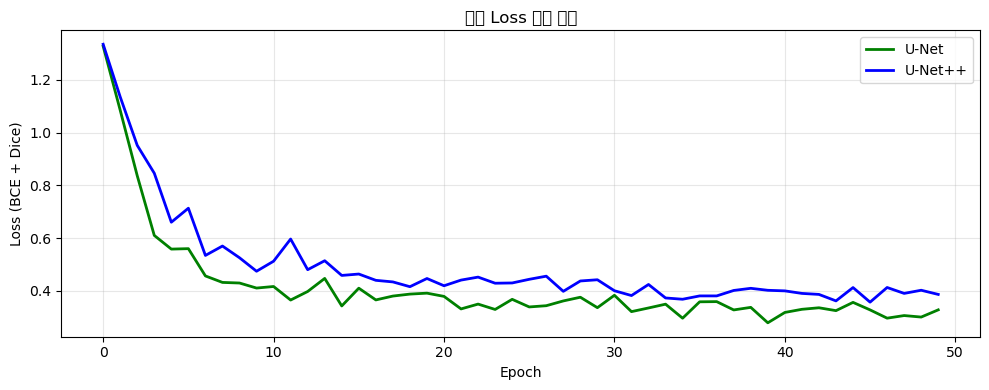

Loss 곡선 저장 완료


In [19]:
# ========================================
# Step 6. 학습 Loss 곡선 비교
# ========================================
plt.figure(figsize=(10, 4))
plt.plot(unet_loss_history,   'g-', label='U-Net',   linewidth=2)
plt.plot(unetpp_loss_history, 'b-', label='U-Net++', linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Loss (BCE + Dice)")
plt.title("학습 Loss 곡선 비교")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(data_dir + '/loss_curves.png', dpi=150)
plt.show()
print("Loss 곡선 저장 완료")

In [20]:
# ========================================
# Step 7. IoU 계산 및 예측 함수 정의
# ========================================
def calculate_iou(target, prediction):
    """
    IoU = |pred ∩ target| / |pred ∪ target|
    1에 가까울수록 좋은 성능
    """
    if target.shape != prediction.shape:
        prediction = resize(
            prediction, target.shape,
            mode='constant', preserve_range=True
        ).astype(np.uint8)
    intersection = np.logical_and(target, prediction).sum()
    union        = np.logical_or(target,  prediction).sum()
    return intersection / (union + 1e-7)


def get_prediction(model, preproc, image_path, label_path=None):
    """모델 추론 및 마스크 생성"""
    origin_img   = imread(image_path)
    processed    = preproc(**{"image": origin_img})
    input_tensor = torch.tensor(
        processed["image"] / 255.0, dtype=torch.float32
    ).permute(2, 0, 1).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(input_tensor)

    mask = (output[0].squeeze().cpu().numpy() > 0.5).astype(np.uint8)
    mask_resized = resize(
        mask, (origin_img.shape[0], origin_img.shape[1]),
        preserve_range=True
    ).astype(np.uint8)

    target = None
    if label_path:
        label_img    = imread(label_path)
        label_proc   = preproc(**{"image": label_img})["image"]
        target       = (label_proc == 7).astype(np.uint8)
        target       = resize(
            target, (origin_img.shape[0], origin_img.shape[1]),
            preserve_range=True
        ).astype(np.uint8)

    return origin_img, mask_resized, target

print("IoU / 예측 함수 정의 완료")

IoU / 예측 함수 정의 완료


/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

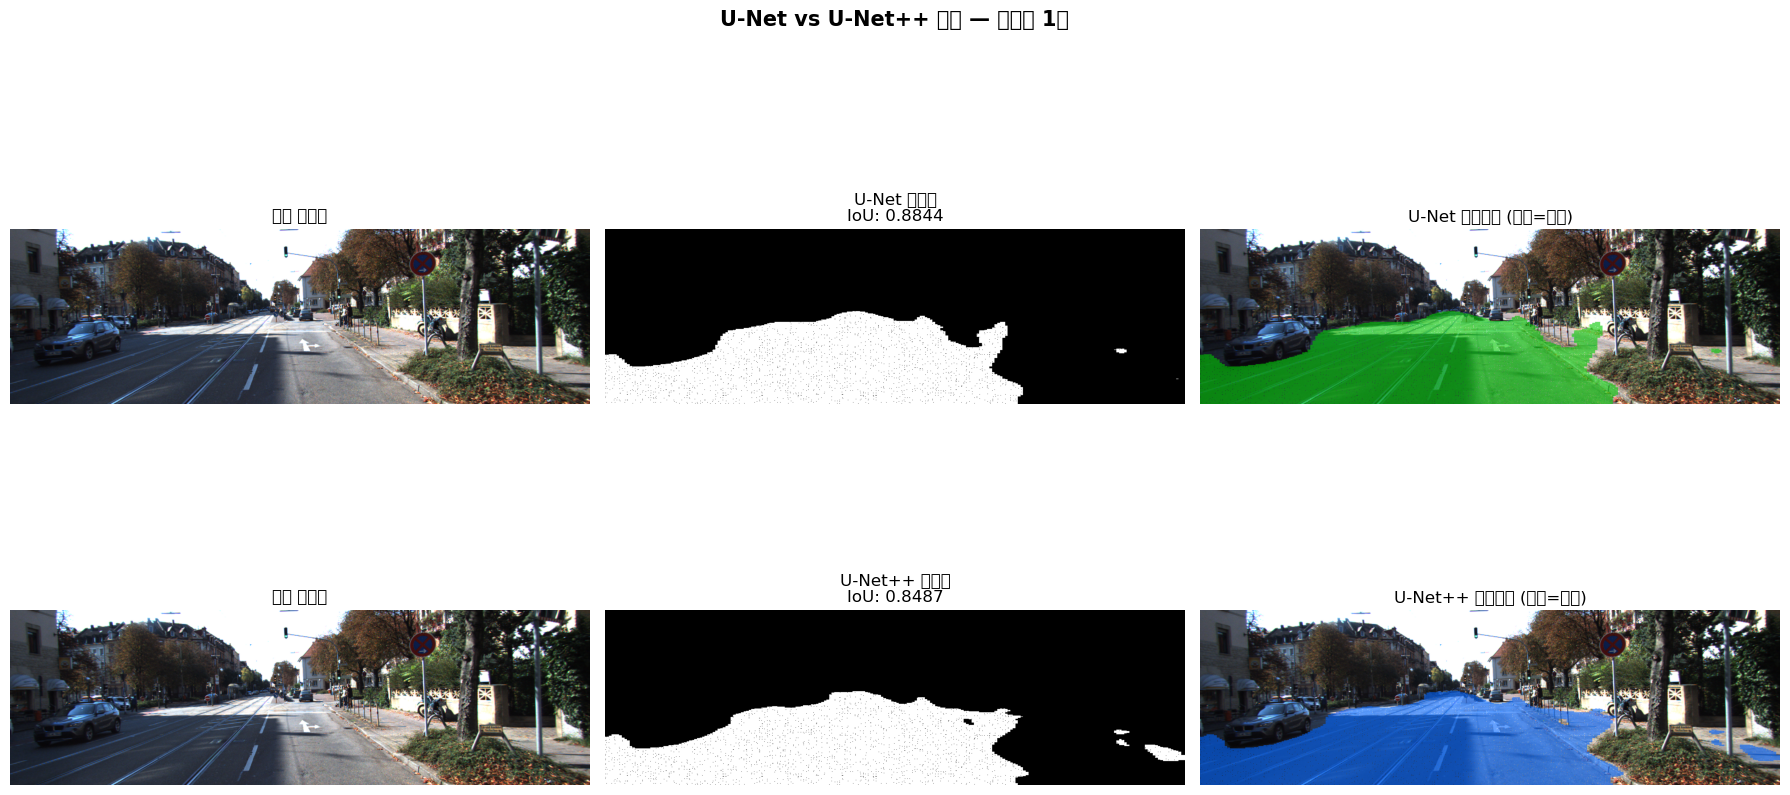

이미지 1번 | U-Net IoU: 0.8844 | U-Net++ IoU: 0.8487 | 향상: +-0.0358


/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

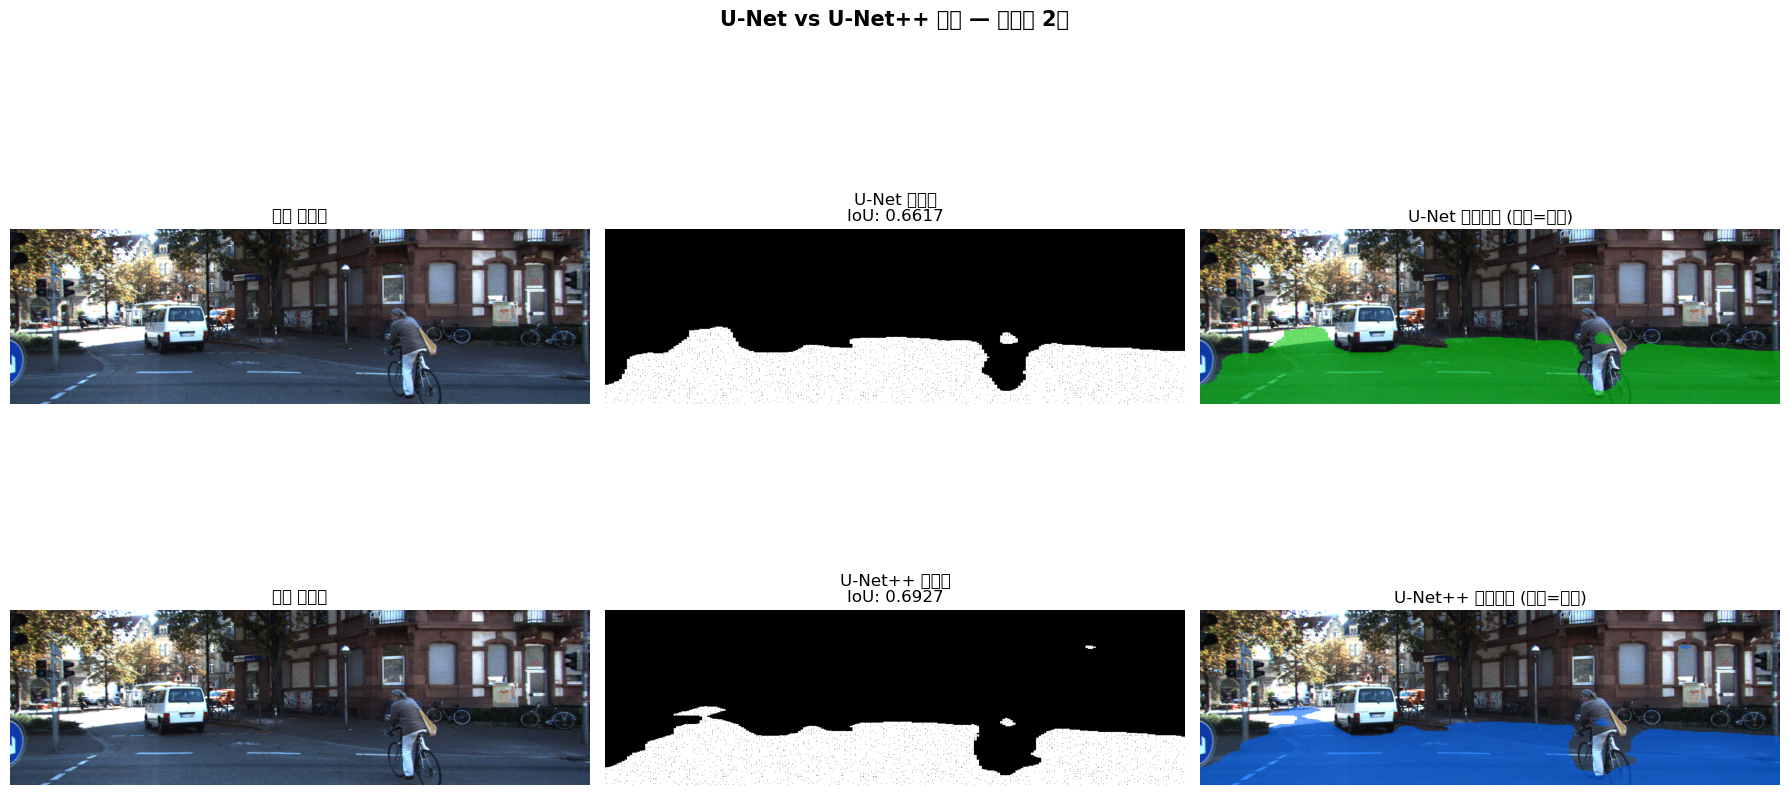

이미지 2번 | U-Net IoU: 0.6617 | U-Net++ IoU: 0.6927 | 향상: +0.0310


/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3056316062.py:38: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tm

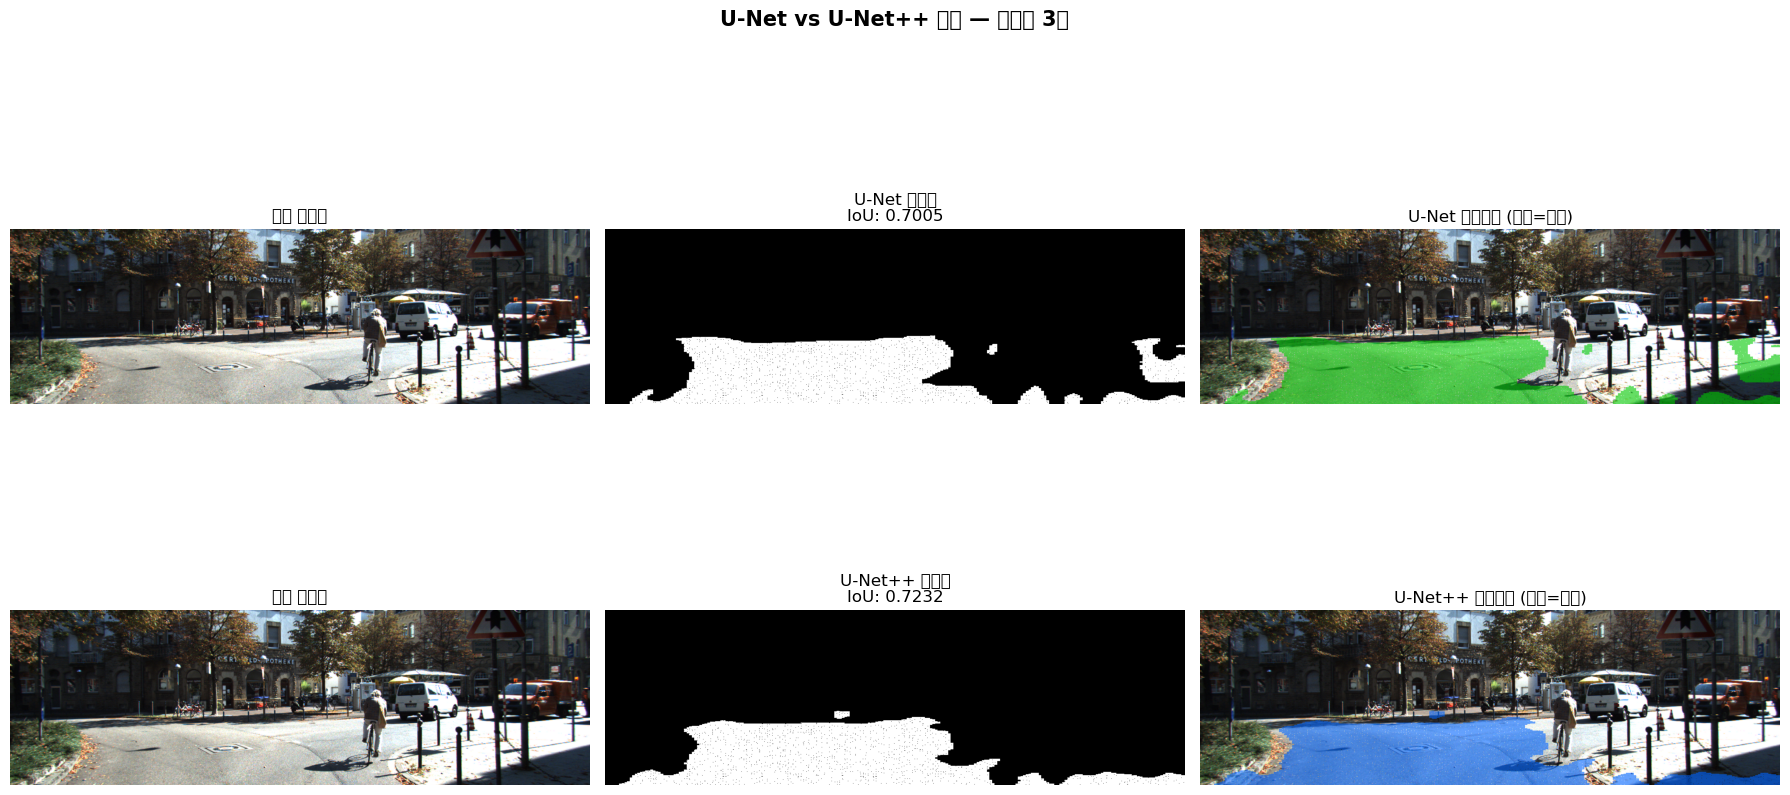

이미지 3번 | U-Net IoU: 0.7005 | U-Net++ IoU: 0.7232 | 향상: +0.0227


In [21]:
# ========================================
# Step 8. 정성적 비교 — 이미지 시각화
#
# 원본 / 예측마스크 / 오버레이를
# U-Net(초록) vs U-Net++(파랑) 나란히 비교
# ========================================
preproc  = build_augmentation(is_train=False)

def visualize_comparison(i=1):
    image_path = data_dir + f'/image_2/00{str(i).zfill(4)}_10.png'
    label_path = data_dir + f'/semantic/00{str(i).zfill(4)}_10.png'

    origin, unet_mask,   target = get_prediction(unet_model,   preproc, image_path, label_path)
    _,      unetpp_mask, _      = get_prediction(unetpp_model, preproc, image_path, label_path)

    unet_iou   = calculate_iou(target, unet_mask)
    unetpp_iou = calculate_iou(target, unetpp_mask)

    def make_overlay(img, mask, color):
        overlay = img.copy()
        overlay[mask == 1] = (overlay[mask == 1] * 0.4 + np.array(color) * 0.6).astype(np.uint8)
        return overlay

    unet_overlay   = make_overlay(origin, unet_mask,   [0, 200,   0])   # 초록
    unetpp_overlay = make_overlay(origin, unetpp_mask, [0, 100, 255])   # 파랑

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f"U-Net vs U-Net++ 비교 — 이미지 {i}번", fontsize=15, fontweight='bold')

    axes[0][0].imshow(origin);              axes[0][0].set_title("원본 이미지");            axes[0][0].axis("off")
    axes[0][1].imshow(unet_mask, cmap="gray"); axes[0][1].set_title(f"U-Net 마스크\nIoU: {unet_iou:.4f}"); axes[0][1].axis("off")
    axes[0][2].imshow(unet_overlay);        axes[0][2].set_title("U-Net 오버레이 (초록=도로)");  axes[0][2].axis("off")

    axes[1][0].imshow(origin);              axes[1][0].set_title("원본 이미지");            axes[1][0].axis("off")
    axes[1][1].imshow(unetpp_mask, cmap="gray"); axes[1][1].set_title(f"U-Net++ 마스크\nIoU: {unetpp_iou:.4f}"); axes[1][1].axis("off")
    axes[1][2].imshow(unetpp_overlay);      axes[1][2].set_title("U-Net++ 오버레이 (파랑=도로)"); axes[1][2].axis("off")

    plt.tight_layout()
    plt.savefig(data_dir + f'/comparison_{str(i).zfill(3)}.png', dpi=150)
    plt.show()

    print(f"이미지 {i}번 | U-Net IoU: {unet_iou:.4f} | U-Net++ IoU: {unetpp_iou:.4f} | 향상: +{unetpp_iou-unet_iou:.4f}")
    return unet_iou, unetpp_iou

# i 값을 바꾸면 다른 이미지 확인 가능
for i in [1, 2, 3]:
    visualize_comparison(i=i)


  전체 테스트셋 평균 IoU 비교 (n=10장)
  U-Net   평균 IoU : 0.771936
  U-Net++ 평균 IoU : 0.738134
  향상도             : +-0.033802


/tmp/ipykernel_109/3633251938.py:53: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3633251938.py:53: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3633251938.py:53: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3633251938.py:53: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3633251938.py:53: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3633251938.py:53: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_109/3633251938.py:53: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/t

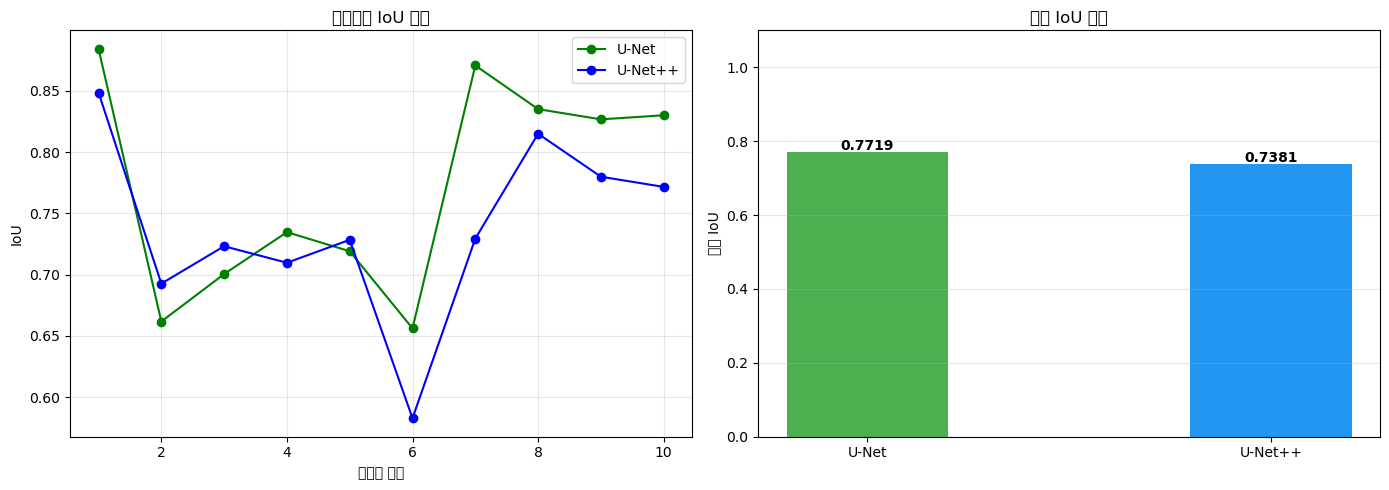

In [22]:
# ========================================
# Step 9. 정량적 비교 — 전체 테스트셋 IoU
# ========================================
def compare_all_test(n=10):
    unet_ious, unetpp_ious = [], []

    for i in range(1, n + 1):
        image_path = data_dir + f'/image_2/00{str(i).zfill(4)}_10.png'
        label_path = data_dir + f'/semantic/00{str(i).zfill(4)}_10.png'
        if not os.path.exists(image_path):
            continue

        _, unet_mask,   target = get_prediction(unet_model,   preproc, image_path, label_path)
        _, unetpp_mask, _      = get_prediction(unetpp_model, preproc, image_path, label_path)

        unet_ious.append(calculate_iou(target, unet_mask))
        unetpp_ious.append(calculate_iou(target, unetpp_mask))

    mean_unet   = np.mean(unet_ious)
    mean_unetpp = np.mean(unetpp_ious)

    print(f"\n{'='*45}")
    print(f"  전체 테스트셋 평균 IoU 비교 (n={len(unet_ious)}장)")
    print(f"{'='*45}")
    print(f"  U-Net   평균 IoU : {mean_unet:.6f}")
    print(f"  U-Net++ 평균 IoU : {mean_unetpp:.6f}")
    print(f"  향상도             : +{mean_unetpp - mean_unet:.6f}")
    print(f"{'='*45}")

    # 이미지별 IoU 그래프
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x = range(1, len(unet_ious) + 1)
    axes[0].plot(x, unet_ious,   'g-o', label='U-Net',   markersize=6)
    axes[0].plot(x, unetpp_ious, 'b-o', label='U-Net++', markersize=6)
    axes[0].set_xlabel("이미지 번호")
    axes[0].set_ylabel("IoU")
    axes[0].set_title("이미지별 IoU 비교")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    bars = axes[1].bar(['U-Net', 'U-Net++'], [mean_unet, mean_unetpp],
                       color=['#4CAF50', '#2196F3'], width=0.4)
    for bar, val in zip(bars, [mean_unet, mean_unetpp]):
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', fontweight='bold')
    axes[1].set_ylabel("평균 IoU")
    axes[1].set_title("평균 IoU 비교")
    axes[1].set_ylim(0, 1.1)
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig(data_dir + '/iou_comparison.png', dpi=150)
    plt.show()

    return mean_unet, mean_unetpp

mean_unet, mean_unetpp = compare_all_test(n=10)

In [24]:
# ========================================
# Step 10. 최종 결과 요약
# ========================================
print("\n" + "="*50)
print("         최종 결과 요약")
print("="*50)
print(f"  U-Net   평균 IoU : {mean_unet:.6f}")
print(f"  U-Net++ 평균 IoU : {mean_unetpp:.6f}")
print(f"  성능 향상         : +{mean_unetpp - mean_unet:.6f}")
print(f"  향상률             : {(mean_unetpp - mean_unet) / mean_unet * 100:.2f}%")
print("="*50)
print()


         최종 결과 요약
  U-Net   평균 IoU : 0.771936
  U-Net++ 평균 IoU : 0.738134
  성능 향상         : +-0.033802
  향상률             : -4.38%

